In [1]:
import wandb

api = wandb.Api(
    api_key="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"
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={"display_name": {"$regex": "trained_on_.._eval_on_.._..?_shot_01_04_2026_14"}},
    order="-created_at",
    per_page=10
)


In [ ]:
import pandas as pd

rows = []
for run in runs:
    rows.append({
        "run_id": run.id,
        "name": run.name,
        "state": run.state,
        **dict(run.config),
        **dict(run.summary),
    })

df = pd.DataFrame(rows)

df[['train_dataset', 'eval_dataset', 'shot']] = df.name.str.extract(r"trained_on_(..)_eval_on_(..)_(..?)_shot_01_04_2026_14")
df['shot'] = df['shot'].astype(int)

In [58]:
# plot the matrix

pdf = df[[
"train_dataset",
"eval_dataset",
"shot",
"start_test_acc",
"start_test_acc_std",
"test_accuracy",
"test_f1",
"test_roc_auc",]].dropna()

import seaborn as sns
import matplotlib.pyplot as plt
# pivot_table = df.pivot(index='train_dataset', columns='eval_dataset', values='eval_acc')
pdf.to_clipboard()

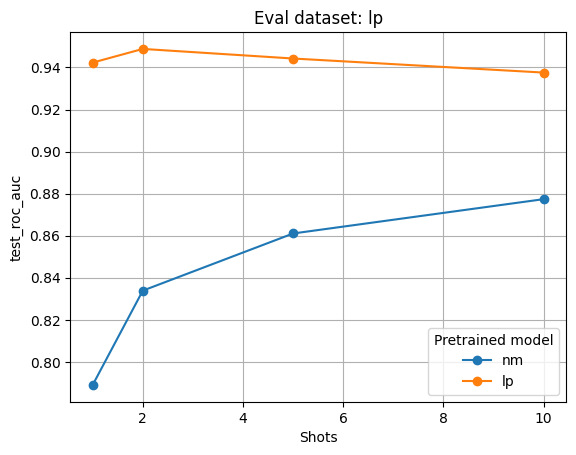

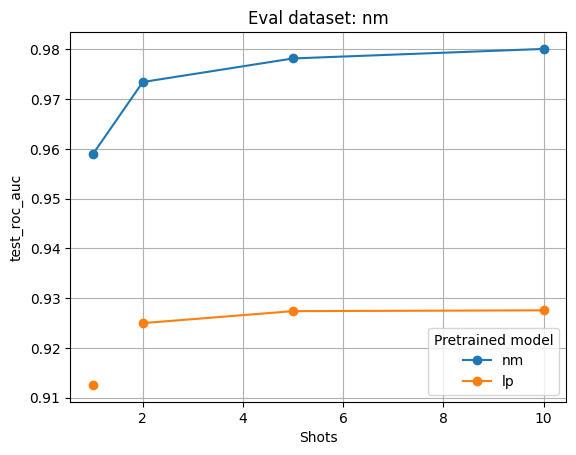

In [63]:
metric = "test_roc_auc"  # change if needed

for eval_ds in df["eval_dataset"].unique():
    plt.figure()
    
    subset = df[df["eval_dataset"] == eval_ds]
    
    for train_ds in subset["train_dataset"].unique():
        sub = subset[subset["train_dataset"] == train_ds].sort_values("shot")
        
        plt.plot(sub["shot"], sub[metric], marker='o', label=train_ds)
    
    plt.title(f"Eval dataset: {eval_ds}")
    plt.xlabel("Shots")
    plt.ylabel(metric)
    plt.legend(title="Pretrained model")
    plt.grid(True)
    
    plt.show()

## PL

In [232]:
import wandb

api = wandb.Api(
    api_key="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"
)


# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    # filters={"display_name": {"$regex": "train1_ukr_rus_twitter"}},
    order="-created_at",
    per_page=10,
    lazy=False
)

In [ ]:
rows = []
for run in runs:
    attrs = getattr(run, "_attrs", {}) or {}
    params = ((attrs.get("config") or {}).get("params") or {})
    summary = attrs.get("summaryMetrics") or {}

    rows.append({
        "run_id": attrs.get("name"),
        "display_name": attrs.get("displayName"),
        "state": attrs.get("state"),
        "dataset": params.get("dataset"),
        "task_name": params.get("task_name"),
        "prefix": params.get("prefix"),
        "pretrained_model_run": params.get("pretrained_model_run"),
        "n_shots": params.get("n_shots"),
        "n_way": params.get("n_way"),
        "n_query": params.get("n_query"),
        "zero_shot": params.get("zero_shot"),
        "test_accuracy": summary.get("test_accuracy"),
        "test_f1": summary.get("test_f1"),
        "test_roc_auc": summary.get("test_roc_auc"),
        "created_at": attrs.get("createdAt"),
        'steps': summary.get("steps"),
    })
df = pd.DataFrame(rows)
df["train1_dataset"] = df["pretrained_model_run"].str.extract(r"train1_(ukr_rus_twitter)_")
df["train1_task"] = df["pretrained_model_run"].str.extract(r"train1_.+?_(nm|pl|lp)_")
df["eval1_task"] = df["task_name"].map({
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
})
df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
# df['is_eval'] = df['display_name'].str.contains(r"eval")
# plot_df = df[df["eval1_task"].isin(EVAL_TASKS) & df["train1_task"].eq("nm")].copy()
df['eval1_dataset'] = df['dataset']
df = df[df.state.ne('running')]
df['created_at'] = pd.to_datetime(df['created_at'])
df['month/day'] = df['created_at'].dt.month.astype(str) + '/' + df['created_at'].dt.day.astype(str)
df = df.sort_values('created_at', ascending=False)
unique_on = ['train1_dataset', 'train1_task', 'eval1_dataset', 'eval1_task', 'n_shots', 'n_query', 'n_way']
allowed_shots = [0, 1, 2, 5, 10]
df = df[df["n_shots"].isin(allowed_shots)]
df = df.drop_duplicates(subset=unique_on, keep='first')
df_ = df.copy()

In [283]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

TRAIN_DATASET = 'ukr_rus_twitter'
EVAL_DATASET = 'ukr_rus_twitter'
EVAL_TASKS = ["nm", "lp", "pl"]
colors = {"nm": "#00b4d8", "lp": "#f72585", "pl": "#80b918"}

i_cross = df.train1_dataset.eq(TRAIN_DATASET) & df.eval1_dataset.eq(EVAL_DATASET)
plot_df_cross = df[i_cross].copy()
i_same = (df.train1_dataset.eq(EVAL_DATASET) & df.eval1_dataset.eq(EVAL_DATASET)
          & df.prefix.str.startswith("trained"))
plot_df_same = df[i_same].dropna()

fig = make_subplots(rows=1, cols=len(EVAL_TASKS), shared_yaxes=True,
                    subplot_titles=[f"Eval: {t.upper()}" for t in EVAL_TASKS])

seen = set()  # dedupe legend across subplots
for col, eval_task in enumerate(EVAL_TASKS, start=1):
    # Cross (solid)
    sub_c = plot_df_cross[plot_df_cross["eval1_task"] == eval_task]
    for tt in sorted(sub_c["train1_task"].dropna().unique()):
        s = sub_c[sub_c["train1_task"] == tt].sort_values("shot_label")
        name = tt.upper()
        fig.add_trace(go.Scatter(
            x=s["shot_label"], y=s["test_roc_auc"],
            mode="lines+markers", name=name,
            legendgroup=name, showlegend=name not in seen,
            line=dict(color=colors.get(tt)),
            customdata=s[["display_name"]].values,
            hovertemplate="<b>%{customdata[0]}</b><br>shots=%{x}<br>AUC=%{y:.3f}<extra></extra>",
        ), row=1, col=col)
        seen.add(name)

    # Same-dataset baseline (dashed)
    sub_s = plot_df_same[plot_df_same["eval1_task"] == eval_task]
    for tt in sorted(sub_s["train1_task"].dropna().unique()):
        s = sub_s[sub_s["train1_task"] == tt].sort_values("shot_label")
        name = f"{tt.upper()} (baseline)"
        fig.add_trace(go.Scatter(
            x=s["shot_label"], y=s["test_roc_auc"],
            mode="lines", name=name,
            legendgroup=name, showlegend=name not in seen,
            line=dict(color=colors.get(tt), dash="dash"), opacity=0.5,
            customdata=s[["display_name"]].values,
            hovertemplate="<b>%{customdata[0]}</b><br>shots=%{x}<br>AUC=%{y:.3f}<extra></extra>",
        ), row=1, col=col)
        seen.add(name)

    fig.update_xaxes(title_text="Shots", row=1, col=col)

fig.update_yaxes(title_text="Test ROC-AUC", row=1, col=1)
fig.update_layout(
    title=f"{TRAIN_DATASET} → {EVAL_DATASET}",
    height=450, width=1100,
    legend=dict(orientation="h", y=-0.2, x=0.5, xanchor="center"),
    hovermode="closest",
)
fig.show()